# RAG vs Vectorless RAG

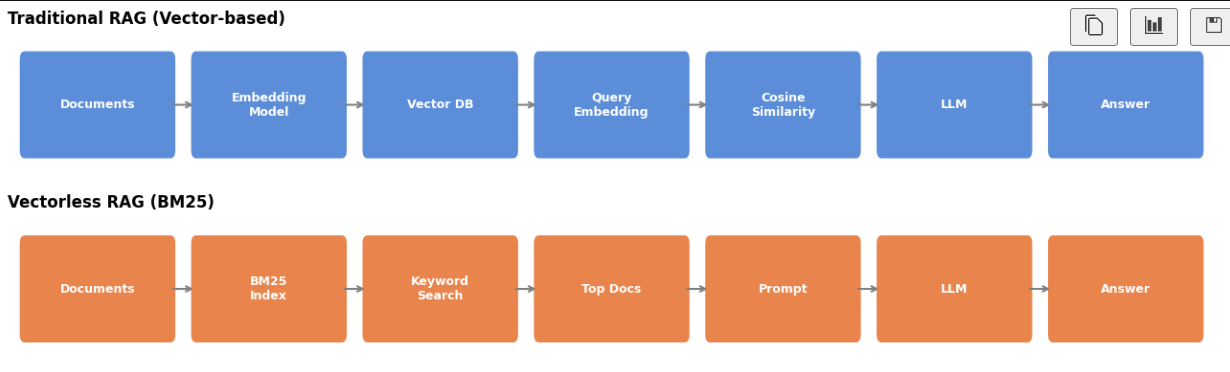

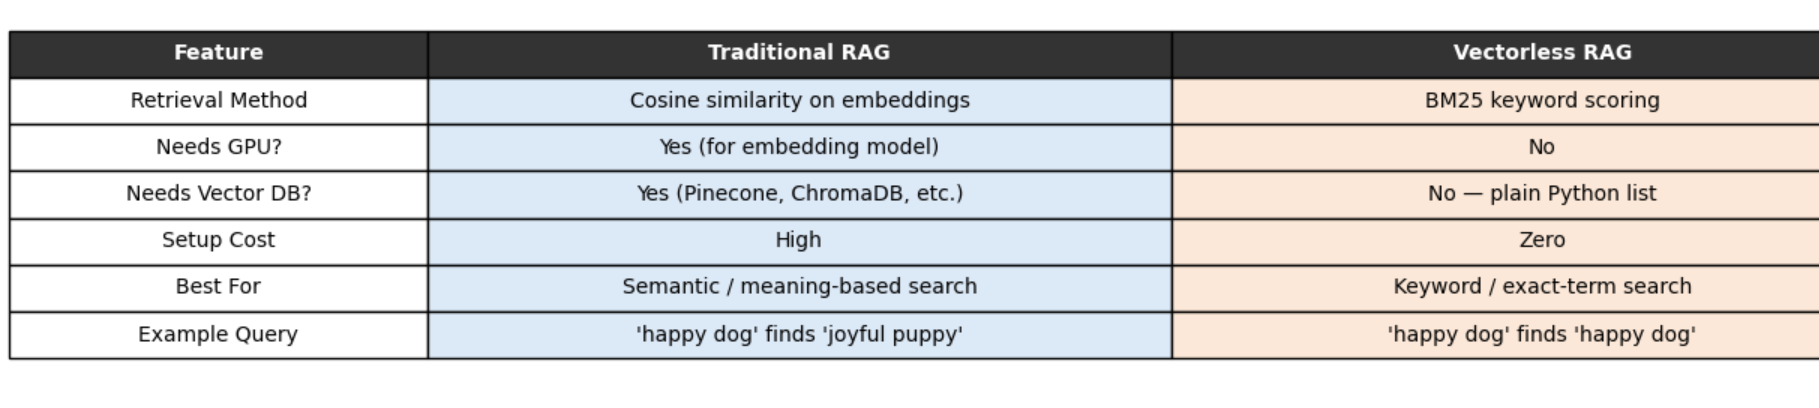

In [8]:
# ── VECTORLESS RAG (BM25) ────────────────────────────────────────
!pip install rank-bm25 -q
from rank_bm25 import BM25Okapi

DOCS = [
    {"title": "BM25",   "content": "BM25 ranks documents by keyword frequency. No embeddings needed."},
    {"title": "RAG",    "content": "RAG fetches relevant documents and sends them to an LLM."},
    {"title": "Django", "content": "Django is a Python web framework with built-in admin and ORM."},
]

bm25 = BM25Okapi([d["content"].lower().split() for d in DOCS])

def vectorless_search(query):
    scores = bm25.get_scores(query.lower().split())
    top    = sorted(range(len(scores)), key=lambda i: scores[i], reverse=True)[:2]
    return [DOCS[i] for i in top if scores[i] > 0]

print("=== Vectorless RAG (BM25) ===")
for doc in vectorless_search("What is BM25?"):
    print(f"  Found: {doc['title']} -> {doc['content']}")

=== Vectorless RAG (BM25) ===
  Found: Django -> Django is a Python web framework with built-in admin and ORM.



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
# ── TRADITIONAL RAG (Embeddings) ─────────────────────────────────
!pip install sentence-transformers -q
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

model      = SentenceTransformer("all-MiniLM-L6-v2")  # small, free model
doc_texts  = [d["content"] for d in DOCS]
doc_embeds = model.encode(doc_texts)  # converts text -> vectors

def vector_search(query):
    q_embed = model.encode([query])
    scores  = cosine_similarity(q_embed, doc_embeds)[0]
    top     = np.argsort(scores)[::-1][:2]
    return [DOCS[i] for i in top]

print("=== Traditional RAG (Embeddings) ===")
for doc in vector_search("What is BM25?"):
    print(f"  Found: {doc['title']} -> {doc['content']}")


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip
c:\Users\Nidhi\Desktop\New folder (2)\vectorless rag\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 1319.14it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


=== Traditional RAG (Embeddings) ===
  Found: BM25 -> BM25 ranks documents by keyword frequency. No embeddings needed.
  Found: RAG -> RAG fetches relevant documents and sends them to an LLM.


In [6]:
# ── Side-by-side on same queries ────────────────────────────────
queries = [
    "keyword frequency ranking",   # exact words -> BM25 wins
    "joyful puppy",                 # no exact match -> embeddings win
]

for q in queries:
    v_res   = vectorless_search(q)
    emb_res = vector_search(q)
    print(f"Query: '{q}'")
    print(f"  BM25      -> {v_res[0]['title'] if v_res else 'No match'}")
    print(f"  Embedding -> {emb_res[0]['title']}")
    print()

Query: 'keyword frequency ranking'
  BM25      -> BM25
  Embedding -> BM25

Query: 'joyful puppy'
  BM25      -> No match
  Embedding -> Django

